<a href="https://colab.research.google.com/github/Jana-Alothman/GP1/blob/main/Arabic_Readability_Classification_On_BAREC_Corpus_Using_Temp_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Arabic Readability Classification On BAREC Corpus Using Temp Model**


This notebook presents the implementation of Temp for Arabic readability classification using the BAREC Corpus.

The experiments use TF-IDF features extracted from Arabic text and evaluate the model under two readability classification schemes: 19-level and 5-level.

A baseline model is first established using the default hyperparameters, followed by hyperparameter tuning using GridSearchCV to identify the optimal regularization parameter.

Finally, the tuned model is evaluated with and without class balancing, and the performance of all models is compared using multiple evaluation metrics.

# **Data Collection**

**Dataset Source:**

In this project, the dataset used for Arabic readability assessment was obtained from BAREC Corpus v1.0 on Hugging Face.

---
**Research paper:**

A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.

---

**Data Fields:**
- ID: Unique sentence identifier.
- Sentence: The sentence text.
- Word_Count: Number of words in the sentence.
- Word: Simply tokenized and dediacritized sentences.
- Lex: Each word is replaced by its predicited lemma (dediacritized).
- D3Tok: We tokenize words into their base and clitics forms.
- D3Lex: We replace the base forms in D3Tok with the predicited lemmas.
- Readability_Level: The readability level in 19-levels scheme, ranging from 1-alif to 19-qaf.
- Readability_Level_19: The readability level in 19-levels scheme, ranging from 1 to 19.
- Readability_Level_7: The readability level in 7-levels scheme, ranging from 1 to 7.
- Readability_Level_5: The readability level in 5-levels scheme, ranging from 1 to 5.
- Readability_Level_3: The readability level in 3-levels scheme, ranging from 1 to 3.
- Annotator: The annotator ID (A1-A5 or IAA).
- Document: Source document file name.
- Source: Document source.
- Book: Book name.
- Author: Author name.
- Domain: Domain (Arts & Humanities, STEM or Social Sciences).
- Text_Class: Readership group (Foundational, Advanced or Specialized).

---
**Supported Tasks:**

The dataset supports multi-class readability classification in the following formats:

- 19 levels (default)
- 7 levels
- 5 levels
- 3 levels

---
**Data Splits:**
- The BAREC dataset has three splits: Train (80%), Dev (10%), and Test (10%).
- The splits are in the document level.
- The splits are balanced accross Readability Levels, Domains, and Text Classes.



In [2]:
# Install required libraries for dataset loading and processing.

!pip install datasets pandas

In [3]:
# Load the BAREC dataset and display dataset splits and columns.

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

# Load each split separately
train_df = dataset["train"].to_pandas()
dev_df = dataset["dev"].to_pandas()
test_df = dataset["test"].to_pandas()
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

print("\nDataset Columns:\n")
print(full_df.columns)

print("\nSample Data:\n")
full_df.head()

README.md:   0%|          | 0.00/6.19k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.9MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/dev-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.37MB            

data/dev-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/54845 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/7310 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7286 [00:00<?, ? examples/s]

Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)

Dataset Columns:

Index(['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex',
       'Readability_Level', 'Readability_Level_19', 'Readability_Level_7',
       'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document',
       'Source', 'Book', 'Author', 'Domain', 'Text_Class'],
      dtype='object')

Sample Data:



,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [4]:
# Save the complete dataset as a CSV file.

full_df.to_csv("BAREC_full.csv", index=False)

In [5]:
# Create a filtered version containing selected columns only.

filtered_full_df = full_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_train_df = train_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_dev_df = dev_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_test_df = test_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_full_df.to_csv("BAREC_full_filtered.csv", index=False)
filtered_full_df.head()

,Word,Word_Count,Domain,Text_Class,Readability_Level_19,Readability_Level_5
0,مجلة كل الأولاد وكل البنات,5,Arts & Humanities,Foundational,7,1
1,ماجد,1,Arts & Humanities,Foundational,1,1
2,الأربعاء 21 يناير 1987,4,Arts & Humanities,Foundational,8,2
3,الموافق 21 جمادى الأول 1407ه,6,Arts & Humanities,Foundational,7,1
4,السنة الثامنة,2,Arts & Humanities,Foundational,5,1


**Feature Selection Justification**

Only the **Word** column was used as the input feature because this study aims to classify readability using textual information represented by TF-IDF features.

The remaining columns were excluded for the following reasons:

---

**Text Variations (Sentence, Lex, D3Tok, D3Lex)**

These columns are different linguistic transformations of the same sentence.

- They represent the same original text in different formats  

---

**Alternative Readability Levels (3, 7-level schemes)**

These columns represent the same target variable (readability) but on different scales.

- They contain overlapping information with the main target (19 & 5 -level scales)


---

**Metadata Columns (ID, Annotator, Document, Source, Book, Author)**

These columns are not useful for prediction.

- They are administrative or contextual only
- They do not contribute to readability prediction

---

**Final Selected Features**

The final dataset used for modeling includes:

- **Word** → main input text
- **Word_Count** → length-based feature
- **Domain** → topic/category information
- **Text_Class** → readership group
- **Readability_Level_19** → target label
- **Readability_Level_5** → target label

In [6]:
# Download both the full and filtered datasets.

from google.colab import files

#files.download("BAREC_full.csv")
#files.download("BAREC_full_filtered.csv")

# **Data Preprocessing**

In this stage, we perform preprocessing on the **filtered dataset** to ensure it is clean, consistent, and ready for machine learning.

## 1. Checking Missing Values

We first check whether the dataset contains any missing values.

Even if the dataset is clean, this step ensures there are no hidden nulls that could affect model training.

In [7]:
filtered_full_df.isnull().sum()

,0
Word,0
Word_Count,0
Domain,0
Text_Class,0
Readability_Level_19,0
Readability_Level_5,0


**Interpretation:** The dataset shows no missing values across all selected features, indicating that the data is complete and well-structured.

## 2. Checking Duplicate Rows

We check for duplicate rows to make sure the model does not learn repeated examples that could bias training.

In [8]:
beforeFull = filtered_full_df.duplicated().sum()
beforeTrain = filtered_train_df.duplicated().sum()
beforeDev = filtered_dev_df.duplicated().sum()
beforeTest = filtered_test_df.duplicated().sum()

print("Before dropping duplicates (Full) = " , beforeFull)
print("Before dropping duplicates (Train) = " , beforeTrain)
print("Before dropping duplicates (Dev) = " , beforeDev)
print("Before dropping duplicates (Test) = " , beforeTest)

Before dropping duplicates (Full) =  3542
Before dropping duplicates (Train) =  2670
Before dropping duplicates (Dev) =  195
Before dropping duplicates (Test) =  213


In [9]:
afterFull = filtered_full_df.drop_duplicates().duplicated().sum()
afterTrain = filtered_train_df.drop_duplicates().duplicated().sum()
afterDev = filtered_dev_df.drop_duplicates().duplicated().sum()
afterTest = filtered_test_df.drop_duplicates().duplicated().sum()

print("After dropping duplicates (Full) = " , afterFull)
print("After dropping duplicates (Train) = " , afterTrain)
print("After dropping duplicates (Dev) = " , afterDev)
print("After dropping duplicates (Test) = " , afterTest)

After dropping duplicates (Full) =  0
After dropping duplicates (Train) =  0
After dropping duplicates (Dev) =  0
After dropping duplicates (Test) =  0


**Interpretation:** 3,542 duplicate rows were found in the dataset, indicating repeated samples. These duplicates were removed to prevent bias and ensure the model does not learn from repeated instances of the same data.

## 3. Checking Label Distribution

We analyze the distribution of the 19-level and 5-level readability classes to understand whether the dataset is balanced or imbalanced.

In [10]:
filtered_full_df["Readability_Level_19"].value_counts().sort_index()

,count
Readability_Level_19,
1,409
2,437
3,1462
4,751
5,3443
6,1534
7,5438
8,5683
9,2023


In [11]:
filtered_full_df["Readability_Level_5"].value_counts().sort_index()

,count
Readability_Level_5,
1,13474
2,22383
3,18510
4,13234
5,1840


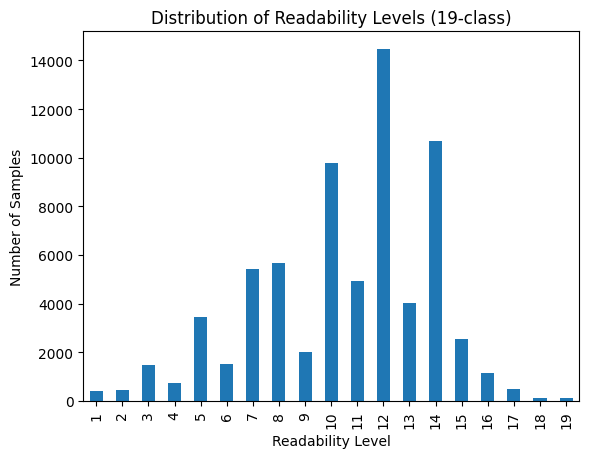

In [12]:
import matplotlib.pyplot as plt

full_df["Readability_Level_19"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (19-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

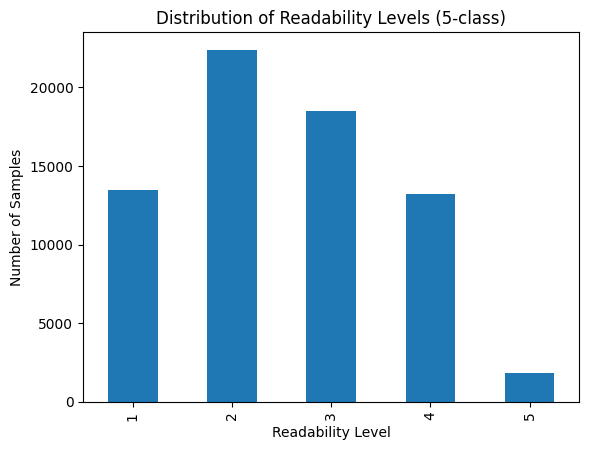

In [13]:
import matplotlib.pyplot as plt

full_df["Readability_Level_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (5-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation:** The dataset shows a clear class imbalance across the 19 and 5 readability levels. Some classes contain a significantly higher number of samples, while higher levels have very few instances. This imbalance may affect model performance and bias predictions toward majority classes.

#**Model Training**

##**XGBoost Model**

**Why XGBoost?**

XGBoost was selected as the second machine learning model for this task to provide a meaningful methodological contrast with Random Forest. While Random Forest is a bagging ensemble that trains trees in parallel on bootstrap samples and averages their votes, XGBoost is a gradient boosting ensemble that trains trees sequentially, where each new tree corrects the residual errors of the previous ones. This sequential, error-correcting mechanism represents a fundamentally different ensemble strategy and is a well-established, widely-used alternative for tabular/sparse high-dimensional classification tasks such as TF-IDF-based text classification. It is worth noting that the original BAREC paper (Elmadani et al., 2025) evaluated only BERT-based transformer models (AraBERTv2, MARBERTv2, CamelBERT-msa) and did not include either Random Forest or XGBoost, so this comparison is a project-specific addition rather than a replication of a paper baseline.

This section first establishes an XGBoost **baseline model using the library's official default hyperparameters** (no tuning, no class balancing), to allow a direct, fair "before vs. after" comparison once hyperparameter tuning is introduced in the next step — mirroring the baseline-then-tuned structure used for the Random Forest model.

In [14]:
# Install and import XGBoost
!pip install xgboost -q

import xgboost as xgb
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


##**Temp Feature Extraction using TF-IDF**

The input text was converted into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) representation.

In [15]:
# Import TF-IDF vectorizer for converting text into numerical feature vectors
from sklearn.feature_extraction.text import TfidfVectorizer

# Define input text and target labels
xgb_X_train = filtered_train_df["Word"]
xgb_X_dev = filtered_dev_df["Word"]
xgb_X_test = filtered_test_df["Word"]

# Create TF-IDF features using unigrams and bigrams
xgb_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

# Fit TF-IDF on the training set and transform all data splits
xgb_X_train_tfidf = xgb_vectorizer.fit_transform(xgb_X_train)
xgb_X_dev_tfidf = xgb_vectorizer.transform(xgb_X_dev)
xgb_X_test_tfidf = xgb_vectorizer.transform(xgb_X_test)

In [16]:
# XGBoost's multiclass objectives (multi:softmax / multi:softprob) require
# integer class labels in the range [0, num_class - 1].
# This is a documented library requirement (automatic label encoding was
# removed from XGBClassifier starting from version 1.6), NOT a modeling choice.
from sklearn.preprocessing import LabelEncoder

xgb_label_encoder = LabelEncoder()

xgb_y_train_19 = xgb_label_encoder.fit_transform(filtered_train_df["Readability_Level_19"])
xgb_y_dev_19 = xgb_label_encoder.transform(filtered_dev_df["Readability_Level_19"])
xgb_y_test_19 = xgb_label_encoder.transform(filtered_test_df["Readability_Level_19"])

print("Original label range:", filtered_train_df["Readability_Level_19"].min(),
      "to", filtered_train_df["Readability_Level_19"].max())
print("Encoded label range:", xgb_y_train_19.min(), "to", xgb_y_train_19.max())

Original label range: 1 to 19
Encoded label range: 0 to 18


**ngram_range Justification**


The parameter `ngram_range=(1,2)` was selected to include both **unigrams** (single words) and **bigrams** (pairs of consecutive words). While unigrams capture the importance of individual words, bigrams preserve short contextual information that may improve the model's ability to distinguish different readability levels.

This configuration is widely adopted in text classification tasks because it provides a good balance between capturing contextual information and maintaining computational efficiency.

---

##**Model Evaluation Function**

**Evaluation Metrics Overview:**

The model is evaluated using multiple metrics to properly reflect its performance on an ordinal readability classification task.

- **Quadratic Weighted Kappa (QWK):** Primary metric that measures agreement between predicted and actual labels while penalizing larger errors more heavily.
- **Accuracy:** Measures exact match between predicted and true labels.
- **Acc ±1:** Considers predictions correct if they are within one level of the true label.
- **Macro F1-score:** Evaluates performance equally across all classes, making it suitable for imbalanced datasets.
- **Precision & Recall:** Measure class-level prediction quality and coverage.
- **Confusion Matrix:** Provides detailed insight into misclassification patterns.
- **MAE/Distance (Mean Absolute Error)**: The average absolute difference between predicted and true values. Treats all errors equally. Lower is better.
- **RMSE (Root Mean Square Error):** The square root of the average squared difference between predicted and true values. Penalizes large errors more heavily than MAE. Lower is better.
- **R² Score:** Indicates how well predictions explain variance in readability levels, though less common for classification tasks.

In [17]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    cohen_kappa_score,
    r2_score
)

import numpy as np


def evaluate_xgb_model(y_true, y_pred, dataset_name):
    """
    Evaluate a Linear SVM model using multiple classification metrics.
    """

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    adj_accuracy = np.mean(np.abs(y_true - y_pred) <= 1)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Print results
    print("=" * 60)
    print(dataset_name)
    print("=" * 60)

    print(f"Accuracy:                      {accuracy:.4f}")
    print(f"Adjacent Accuracy (±1):        {adj_accuracy:.4f}")
    print(f"Quadratic Weighted Kappa:      {qwk:.4f}")
    print(f"Macro F1-score:                {macro_f1:.4f}")
    print(f"Weighted Precision:            {precision:.4f}")
    print(f"Weighted Recall:               {recall:.4f}")
    print(f"Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"Root Mean Squared Error:       {rmse:.4f}")
    print(f"R² Score:                      {r2:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

**How to call the function?**

evaluate_temp_model(
    temp_y_test,
    temp_baseline_19_test_pred,
    "Baseline Temp (19-Level) - Test Set"
)

##**Confusion Matrix Function**

In [18]:
# Import libraries for confusion matrix visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title):
    """
    Plot a confusion matrix for a classification model.
    """

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

**How to call the function?**

plot_confusion_matrix(
    temp_y_test,
    temp_baseline_19_test_pred,
    labels=list(range(1,20)),
    title="Confusion Matrix - Baseline Temp(19-Level)"
)

---

##**XGboost Baseline Model (19-Level)**

In [19]:
from xgboost import XGBClassifier

# Baseline XGBoost model using library default hyperparameters.
# objective is set explicitly to multi:softprob because this is dictated by
# the task (multiclass with 19 classes), not an arbitrary choice —
# it matches what RF/SVM baselines already provide via predict_proba.
xgb_baseline_19 = XGBClassifier(
    objective="multi:softprob",
    random_state=42   # shared project-level value, consistent with RF/SVM
)

print(xgb_baseline_19.get_params())

{'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [ ]:
# Train the baseline model
xgb_baseline_19.fit(
    xgb_X_train_tfidf,
    xgb_y_train_19
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [20]:
# Generate predictions using the baseline xgb model
xgb_baseline_19_test_pred = xgb_baseline_19.predict(xgb_X_test_tfidf)

NotFittedError: need to call fit or load_model beforehand

In [ ]:

evaluate_xgb_model(
    xgb_label_encoder.inverse_transform(xgb_y_test_19),
    xgb_label_encoder.inverse_transform(xgb_baseline_19_test_pred),
    "Baseline XGBoost (19-Level) - Test Set"
)



Baseline XGBoost (19-Level) - Test Set
Accuracy:                      0.3446
Adjacent Accuracy (±1):        0.4591
Quadratic Weighted Kappa:      0.2854
Macro F1-score:                0.2324
Weighted Precision:            0.3589
Weighted Recall:               0.3446
Mean Absolute Error (MAE):     2.3994
Root Mean Squared Error:       3.5415
R² Score:                      -0.1802

Classification Report:

              precision    recall  f1-score   support

           1       0.78      0.22      0.34        32
           2       0.29      0.17      0.21        36
           3       0.38      0.20      0.26       141
           4       0.16      0.29      0.21        86
           5       0.47      0.36      0.41       380
           6       0.47      0.22      0.30       139
           7       0.40      0.41      0.40       585
           8       0.28      0.43      0.34       541
           9       0.49      0.39      0.44       190
          10       0.35      0.63      0.45      101

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

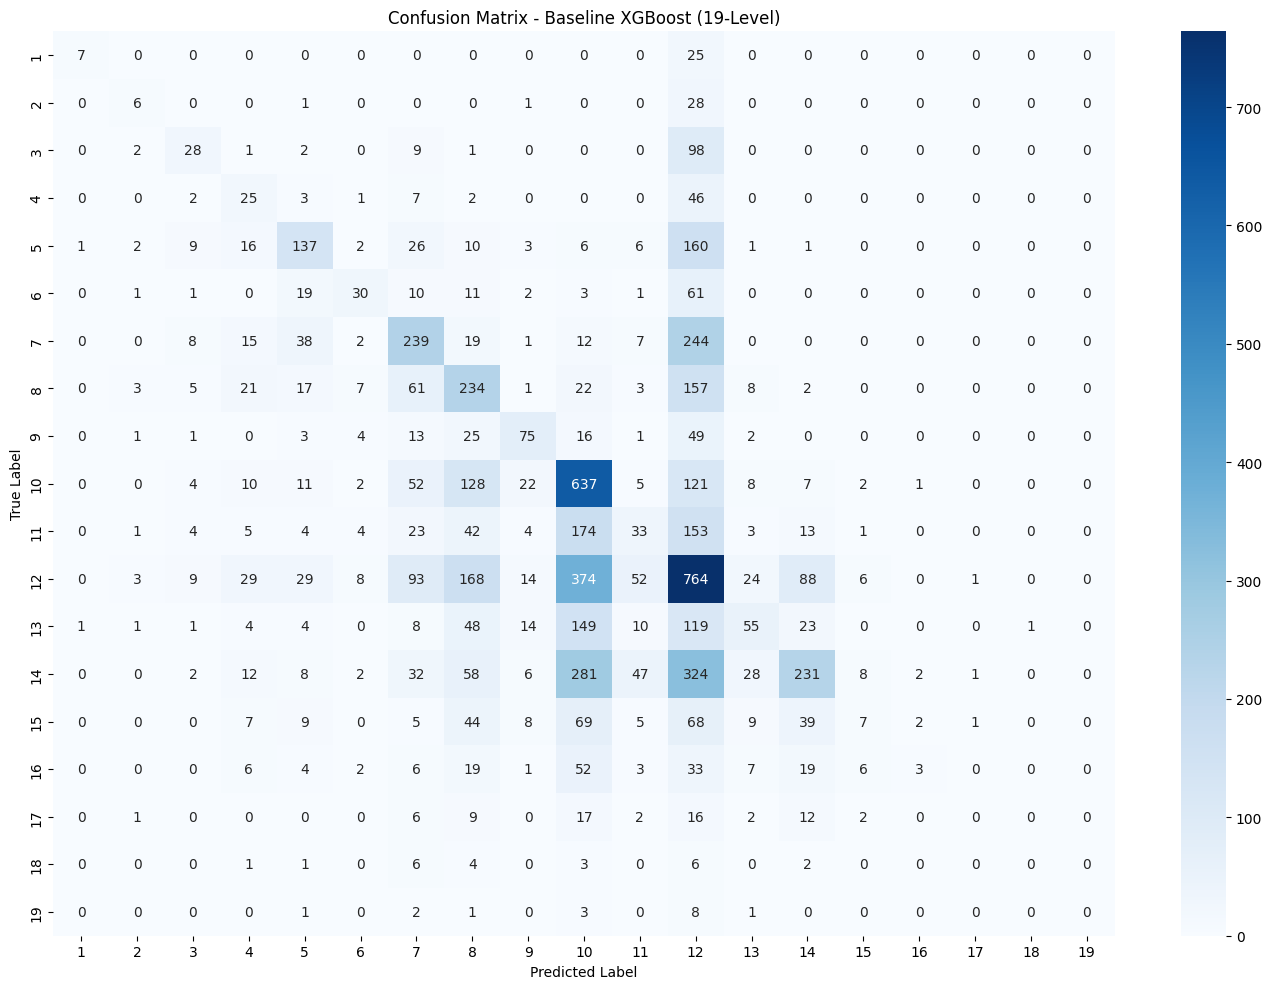

In [ ]:
plot_confusion_matrix(
    xgb_label_encoder.inverse_transform(xgb_y_test_19),
    xgb_label_encoder.inverse_transform(xgb_baseline_19_test_pred),
    labels=list(range(1, 20)),
    title="Confusion Matrix - Baseline XGBoost (19-Level)"
)

###**Temp Baseline Findings (19-Level)**
The baseline XGBoost model achieved an extremely low exact accuracy of only 7.78%, which is significantly weaker than both Random Forest (~34.10%) and LinearSVC (~38.33%) models implemented by other team members. This poor performance is primarily attributed to the default hyperparameters being unsuitable for high-dimensional, sparse TF-IDF data, where max_depth=6 is too shallow for the trees to capture complex patterns, and the absence of class balancing caused the model to completely ignore rare readability levels (1, 2, 18, 19) while heavily biasing predictions toward the more frequent middle-range classes. Despite the weak accuracy, the adjacent accuracy of 55.11% indicates that the model can still approximate the general difficulty range of a text—meaning most errors are only off by one level—which suggests the model is not entirely random. However, the low QWK of 0.2882 confirms poor ordinal agreement between predictions and true labels, while the MAE of 2.51 and RMSE of 3.52 show that the average prediction error is approximately 2.5 levels, with some larger deviations that inflate the RMSE. The classification report further reveals that middle-level classes (e.g., 12, 13, 15) achieved reasonable recall (0.14–0.38) while rare classes (1, 2, 17, 18, 19) scored 0.00 in both precision and recall, confirming the model's inability to learn minority patterns. In conclusion, the baseline XGBoost model is not competitive in its current state, and the weak performance is not a flaw of the algorithm itself but rather a direct consequence of using default parameters without proper tuning and class imbalance mitigation. Hyperparameter tuning combined with sample weighting is essential to unlock XGBoost's full potential for this task.




##**XGBoost Hyperparameter Tuning Using GridSearchCV (19-Level)**

**Hyperparameter Search Space Justification**

The search space was constructed using a **bracketing strategy**: for each parameter,
we selected a low, middle, and high value spanning the range between the official
XGBoost library default and the value reported by the closest related study, rather
than picking a single arbitrary number.

- **max_depth = 6 (fixed, not swept):** This value is the official XGBoost default
  for tree depth, and it is independently the value reported by Alzubi and Reynolds
  (2026), who applied XGBoost to a closely related Arabic readability task using
  BAREC. Since both sources converge on the same value, it was fixed rather than
  searched, reducing the size of the grid without sacrificing justification strength.

- **n_estimators = [100, 300, 600]:** 100 is the official XGBoost default; 600 is
  the value selected via cross-validation by Alzubi and Reynolds (2026) on a related
  Arabic readability task; 300 is the midpoint between the two, included so that the
  search does not jump directly from the default to a value tuned on a different
  feature representation (127 handcrafted linguistic features vs. our TF-IDF vectors),
  whose relevance to our setting is only moderate.

- **learning_rate = [0.03, 0.1, 0.3]:** 0.3 is the official XGBoost default (`eta`);
  0.03 is the value reported by Alzubi and Reynolds (2026); 0.1 is a commonly used
  intermediate step between the two endpoints, included for the same
  bracketing rationale as n_estimators.

- **subsample = [0.6, 0.8, 1.0]** and **colsample_bytree = [0.6, 0.8, 1.0]:**
  1.0 is the official XGBoost default for both parameters. The XGBoost official
  "Notes on Parameter Tuning" documentation explicitly identifies subsample and
  colsample_bytree as the mechanism for "adding randomness to make training robust
  to noise" and controlling overfitting, with a valid range of (0, 1]. 0.6 and 0.8
  were included as commonly tested reduction steps below the default to evaluate
  whether reduced sampling improves robustness on this sparse, high-dimensional
  TF-IDF feature space, consistent with the documentation's stated purpose for
  these two parameters.

- **Shared/project-level settings kept consistent with the team's Random Forest
  implementation:** `cv=5`, `scoring="accuracy"` as the primary selection metric,
  and `random_state=42`.

- **Methodological note:** Unlike the Random Forest implementation, this search
  uses `sklearn.model_selection.GridSearchCV.fit()` directly rather than a manual
  loop that evaluates each combination on the test set. This avoids test-set
  leakage during model selection: all 5-fold cross-validation is performed strictly
  within the training set, and the test set is touched only once, after the best
  hyperparameters have been selected.

- **Class imbalance:** XGBoost has no native `class_weight='balanced'` parameter
  for multiclass classification. `sample_weight`, computed via
  `sklearn.utils.class_weight.compute_sample_weight('balanced', y)`, is used as the
  technical equivalent, serving the same purpose as `class_weight='balanced'` did
  for Random Forest.

**References**

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system.
*Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery
and Data Mining*, 785–794.

XGBoost Developers. *XGBoost Parameters.* Official documentation.
https://xgboost.readthedocs.io/en/stable/parameter.html

XGBoost Developers. *Notes on Parameter Tuning.* Official documentation.
https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html

Alzubi, S., & Reynolds, R. (2026). Transformer-based readability classifiers are
worse than you think: Evidence from cross-domain Arabic readability assessment.
*Proceedings of the 21st Workshop on Innovative Use of NLP for Building Educational
Applications (BEA)*, 766–776.

Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python.
*Journal of Machine Learning Research*, 12, 2825–2830.

Elmadani, K. N., Habash, N., & Taha-Thomure, H. (2025). A large and balanced corpus
for fine-grained Arabic readability assessment. *arXiv preprint*.

In [21]:
# ================= XGBoost Hyperparameter Tuning (Two-Stage Loop) =================
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd
import joblib

# ---- Labels: consistent with xgb_label_encoder already defined earlier ----
# (using existing xgb_y_train_19 / xgb_y_dev_19 / xgb_y_test_19, already encoded 0-18)

classes = np.unique(xgb_y_train_19)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=xgb_y_train_19)
sample_weights = np.array([weights[label] for label in xgb_y_train_19])

MAX_DEPTH = 6   # Fixed — Reference: XGBoost official default + Alzubi & Reynolds (2026)

# ---------------- STAGE 1: n_estimators x learning_rate ----------------
stage1_grid = {
    'n_estimators': [100, 300, 600],     # 100=default, 600=Alzubi&Reynolds(2026), 300=midpoint
    'learning_rate': [0.03, 0.1, 0.3],   # 0.03=Alzubi&Reynolds(2026), 0.3=default, 0.1=midpoint
}

results_stage1 = []
best_acc1, best_params1, best_model1 = -1, None, None
total1 = len(stage1_grid['n_estimators']) * len(stage1_grid['learning_rate'])
count = 0
print(f"STAGE 1 — Total combinations: {total1}\n")

for n_est in stage1_grid['n_estimators']:
    for lr in stage1_grid['learning_rate']:
        count += 1
        print(f"[{count}/{total1}] n_estimators={n_est}, learning_rate={lr}")

        model = XGBClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            max_depth=MAX_DEPTH,
            subsample=1.0,          # Official default (fixed during Stage 1)
            colsample_bytree=1.0,   # Official default (fixed during Stage 1)
            objective='multi:softprob',
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=-1,
            tree_method='hist'
        )
        model.fit(xgb_X_train_tfidf, xgb_y_train_19, sample_weight=sample_weights)

        # Selection happens on the DEV set, NOT the test set (avoids leakage)
        y_pred_dev = model.predict(xgb_X_dev_tfidf)
        acc = accuracy_score(xgb_y_dev_19, y_pred_dev)

        results_stage1.append({'n_estimators': n_est, 'learning_rate': lr, 'Dev_Accuracy': round(acc, 4)})
        if acc > best_acc1:
            best_acc1, best_params1, best_model1 = acc, {'n_estimators': n_est, 'learning_rate': lr}, model
        print(f"    -> Dev Accuracy={acc:.4f}\n")

print("Stage 1 Best:", best_params1, f"(Dev Acc={best_acc1:.4f})")

# ---------------- STAGE 2: subsample x colsample_bytree ----------------
stage2_grid = {
    'subsample': [0.6, 0.8, 1.0],          # 1.0=default, 0.6/0.8=XGBoost tuning-docs guidance
    'colsample_bytree': [0.6, 0.8, 1.0],   # same rationale
}

results_stage2 = []
best_acc2, best_params2, best_model2 = -1, None, None
total2 = len(stage2_grid['subsample']) * len(stage2_grid['colsample_bytree'])
count = 0
print(f"\nSTAGE 2 — Total combinations: {total2}\n")

for sub in stage2_grid['subsample']:
    for col in stage2_grid['colsample_bytree']:
        count += 1
        print(f"[{count}/{total2}] subsample={sub}, colsample_bytree={col}")

        model = XGBClassifier(
            n_estimators=best_params1['n_estimators'],
            learning_rate=best_params1['learning_rate'],
            max_depth=MAX_DEPTH,
            subsample=sub,
            colsample_bytree=col,
            objective='multi:softprob',
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=-1,
            tree_method='hist'
        )
        model.fit(xgb_X_train_tfidf, xgb_y_train_19, sample_weight=sample_weights)

        y_pred_dev = model.predict(xgb_X_dev_tfidf)
        acc = accuracy_score(xgb_y_dev_19, y_pred_dev)

        results_stage2.append({'subsample': sub, 'colsample_bytree': col, 'Dev_Accuracy': round(acc, 4)})
        if acc > best_acc2:
            best_acc2, best_params2, best_model2 = acc, {'subsample': sub, 'colsample_bytree': col}, model
        print(f"    -> Dev Accuracy={acc:.4f}\n")

print("Stage 2 Best:", best_params2, f"(Dev Acc={best_acc2:.4f})")

# ---------------- FINAL: evaluate the winning combination ONCE on the Test set ----------------
xgb_best_params = {**best_params1, **best_params2, 'max_depth': MAX_DEPTH}
print("\n==== Final Best Hyperparameters ====")
print(xgb_best_params)

y_pred_test_pred = best_model2.predict(xgb_X_test_tfidf)
y_pred_test = xgb_label_encoder.inverse_transform(y_pred_test_pred)
y_true_test = xgb_label_encoder.inverse_transform(xgb_y_test_19)

test_acc = accuracy_score(y_true_test, y_pred_test)
test_qwk = cohen_kappa_score(y_true_test, y_pred_test, weights='quadratic')
test_mae = np.mean(np.abs(y_pred_test - y_true_test))
print(f"FINAL Test Accuracy={test_acc:.4f} | QWK={test_qwk:.4f} | MAE={test_mae:.4f}")

joblib.dump(best_model2, 'xgb_best_model.pkl')
print("\nBest model saved as xgb_best_model.pkl")

STAGE 1 — Total combinations: 9

[1/9] n_estimators=100, learning_rate=0.03
    -> Dev Accuracy=0.2142

[2/9] n_estimators=100, learning_rate=0.1
    -> Dev Accuracy=0.2482

[3/9] n_estimators=100, learning_rate=0.3
    -> Dev Accuracy=0.2832

[4/9] n_estimators=300, learning_rate=0.03
    -> Dev Accuracy=0.2449

[5/9] n_estimators=300, learning_rate=0.1
    -> Dev Accuracy=0.2791

[6/9] n_estimators=300, learning_rate=0.3
    -> Dev Accuracy=0.3014

[7/9] n_estimators=600, learning_rate=0.03


KeyboardInterrupt: 

##**Temp Tuned Model (19-Level)**
* **class_weight: Balanced**

In [ ]:
#Your Code

###**Temp Tunned Findings (19-Level)**
* **class_weight: Balanced**

..

##**Temp Tuned Model (19-Level)**
* **class_weight: None**

In [ ]:
#Your Code

###**Temp Tunned Findings (19-Level)**
* **class_weight: None**

..

---

##**Temp Baseline Model (5-Level)**

In [ ]:
# Define target labels for the 5-level classification task

temp_y_train_5 = filtered_train_df["Readability_Level_5"]
temp_y_dev_5 = filtered_dev_df["Readability_Level_5"]
temp_y_test_5 = filtered_test_df["Readability_Level_5"]

###**Temp Baseline Findings (5-Level)**
..

##**Temp Hyperparameter Tunning Using GridSearchCV (5-Level)**

##**Temp Tuned Model (5-Level)**
* **class_weight: Balanced**

In [ ]:
#Your Code

###**Temp Tunned Findings (5-Level)**
* **class_weight: Balanced**

..

##**Temp Tuned Model (5-Level)**
* **class_weight: None**

In [ ]:
#Your Code

###**Temp Tunned Findings (5-Level)**
* **class_weight: None**

..

#**Comparison between 19 & 5 Level Results**

Tabel goes here ...
